# Treatment-deletion sensitivity: BMI ↔ LDL-C correlation among
# the *untreated* population

**Motivation.** `01_correlation.ipynb` reports a NHANES-derived
BMI ↔ LDL-C Spearman correlation that flips sign with age — positive
in young adults, negative in adults 65+. A plausible mechanism is
treatment: high-LDL-C older adults are routinely prescribed statins,
which lower LDL-C without changing BMI. Among the high-BMI elderly
the upper tail of LDL-C is therefore truncated, dragging the
correlation negative. The trial sees the post-treatment population,
so the observed correlation is the right input for Model 2 — but
the *biological* correlation (what BMI ↔ LDL-C looks like in an
untreated body) is the more general parameter, and matters for any
scenario that adds or removes lipid-lowering therapy.

**Approach.** For each NHANES participant who reports currently
taking prescription cholesterol medication, undo the treatment by
multiplying their observed LDL-C by `1 / (1 - δ)`, where δ is a
representative statin LDL-C-lowering fraction. Defaults to δ = 0.30
(~30 % reduction, the central estimate for typical-intensity statin
therapy in real-world adherence-adjusted populations). Re-compute
the BMI ↔ LDL-C Spearman correlation on the deletion-adjusted
values and compare to the as-observed numbers from `01_correlation`.

**Treatment indicator.** NHANES asks `BPQ100D`: "Now taking
prescribed medicine for high cholesterol" (1 = Yes, 2 = No, 7/9 =
refused/don't know). Available identically across cycles 1999–2018.

In [1]:
import hashlib
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadstat
import requests
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR = os.path.abspath(os.path.join("..", "data"))
DERIVED = os.path.join(DATA_DIR, "derived")
RAW_NHANES = os.path.join(DATA_DIR, "raw", "nhanes")
NHANES_BASE = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public"

VNUC_REFERENCE = 0.1118
STATIN_EFFICACY = 0.30  # fractional LDL-C reduction (counterfactual = obs / (1 - δ))

## Download BPQ (cholesterol-medication) files

Same caching helper as `nhanes_vivarium_risk_demo/01_nhanes_to_vivarium`
— already-downloaded files are skipped.

In [2]:
CYCLES = [
    {"label": "1999_2000", "year": 1999, "suffix": ""},
    {"label": "2001_2002", "year": 2001, "suffix": "_B"},
    {"label": "2003_2004", "year": 2003, "suffix": "_C"},
    {"label": "2005_2006", "year": 2005, "suffix": "_D"},
    {"label": "2007_2008", "year": 2007, "suffix": "_E"},
    {"label": "2009_2010", "year": 2009, "suffix": "_F"},
    {"label": "2011_2012", "year": 2011, "suffix": "_G"},
    {"label": "2013_2014", "year": 2013, "suffix": "_H"},
    {"label": "2015_2016", "year": 2015, "suffix": "_I"},
    {"label": "2017_2018", "year": 2017, "suffix": "_J"},
]


def download(url: str, dest: str) -> str:
    if os.path.exists(dest):
        return dest
    print(f"  GET {url}")
    r = requests.get(url, timeout=180)
    r.raise_for_status()
    with open(dest, "wb") as f:
        f.write(r.content)
    md5 = hashlib.md5(r.content).hexdigest()
    print(f"    -> {os.path.basename(dest)} ({len(r.content):,} bytes, md5={md5})")
    return dest


def read_xpt(path: str) -> pd.DataFrame:
    try:
        df, _ = pyreadstat.read_xport(path)
    except UnicodeDecodeError:
        df, _ = pyreadstat.read_xport(path, encoding="latin1")
    return df


bpq_frames = {}
for cyc in CYCLES:
    cdir = os.path.join(RAW_NHANES, cyc["label"])
    os.makedirs(cdir, exist_ok=True)
    fname = f"BPQ{cyc['suffix']}.xpt"
    url = f"{NHANES_BASE}/{cyc['year']}/DataFiles/{fname}"
    dest = os.path.join(cdir, fname)
    download(url, dest)
    bpq_frames[cyc["label"]] = read_xpt(dest)
    print(f"  {cyc['label']}: {fname} -> {len(bpq_frames[cyc['label']]):,} rows")

  GET https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/BPQ.xpt


    -> BPQ.xpt (1,746,480 bytes, md5=01f67f9bf2758cc2e2e7f24ca26b0f37)
  1999_2000: BPQ.xpt -> 6,044 rows
  GET https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2001/DataFiles/BPQ_B.xpt


    -> BPQ_B.xpt (1,916,400 bytes, md5=aabfd4108928c9c63c94445df0f481c3)
  2001_2002: BPQ_B.xpt -> 6,634 rows
  GET https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2003/DataFiles/BPQ_C.xpt


    -> BPQ_C.xpt (1,795,120 bytes, md5=2bcab755248de146bba011c3e5d2896b)
  2003_2004: BPQ_C.xpt -> 6,213 rows
  GET https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2005/DataFiles/BPQ_D.xpt


    -> BPQ_D.xpt (788,800 bytes, md5=d5a11938817f358f0b9ed6045e694680)
  2005_2006: BPQ_D.xpt -> 6,139 rows
  GET https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2007/DataFiles/BPQ_E.xpt


...

    -> BPQ_F.xpt (1,161,040 bytes, md5=fb46f8e39e80ca23d562bd43751232f8)
  2009_2010: BPQ_F.xpt -> 6,889 rows
  GET https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2011/DataFiles/BPQ_G.xpt


    -> BPQ_G.xpt (743,920 bytes, md5=6bd9225ce7b707a031f1dbe31d4127f2)
  2011_2012: BPQ_G.xpt -> 6,175 rows
  GET https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2013/DataFiles/BPQ_H.xpt


    -> BPQ_H.xpt (726,720 bytes, md5=8b6463e652049319381be8cb056462d3)
  2013_2014: BPQ_H.xpt -> 6,464 rows
  GET https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/BPQ_I.xpt


    -> BPQ_I.xpt (559,120 bytes, md5=618e1b3dcb9e964aeb72b564d93c90d8)
  2015_2016: BPQ_I.xpt -> 6,327 rows
  GET https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BPQ_J.xpt


    -> BPQ_J.xpt (544,560 bytes, md5=73389571d1c6c3042b233b0277e4bcb3)
  2017_2018: BPQ_J.xpt -> 6,161 rows


## Merge BPQ with the prepared derived parquets

Key on `SEQN`; restrict to adults with both BMI and LDL-C measured
(matching the population used in `01_correlation`).

In [3]:
def load_with_treatment(cycle_label: str) -> pd.DataFrame:
    df = pd.read_parquet(os.path.join(DERIVED, f"{cycle_label}.parquet"))
    df = df[["SEQN", "AGE", "FEMALE", "BMXBMI", "LBDLDL", "WTMEC2YR"]].copy()
    df["CYCLE"] = cycle_label

    bpq = bpq_frames[cycle_label]
    if "BPQ100D" not in bpq.columns:
        raise RuntimeError(f"{cycle_label}: BPQ100D missing from BPQ file")
    bpq = bpq[["SEQN", "BPQ100D"]].copy()
    df = df.merge(bpq, on="SEQN", how="left")
    df["on_chol_med"] = (df["BPQ100D"] == 1.0).astype(int)
    return df


pooled = pd.concat([load_with_treatment(c["label"]) for c in CYCLES], ignore_index=True)
adults = pooled.query("AGE >= 20 and BMXBMI.notna() and LBDLDL.notna()").copy()
adults["WT_POOLED"] = adults["WTMEC2YR"] / len(CYCLES)

print(f"Adult records with both BMI and LDL-C: {len(adults):,}")
print(f"  on cholesterol medication: {adults['on_chol_med'].sum():,} "
      f"({100 * adults['on_chol_med'].mean():.1f}%)")

# Treatment prevalence by age band — the mechanism we expect:
adults["age_band"] = pd.cut(
    adults["AGE"],
    bins=[20, 30, 40, 50, 60, 70, 80, 200],
    right=False,
    labels=["20–29", "30–39", "40–49", "50–59", "60–69", "70–79", "80+"],
)
tx_by_age = adults.groupby("age_band", observed=True).agg(
    n=("on_chol_med", "size"),
    on_med_pct=("on_chol_med", lambda s: 100 * s.mean()),
)
print("\nCholesterol medication prevalence by age band:")
print(tx_by_age.round(1).to_string())

Adult records with both BMI and LDL-C: 22,414
  on cholesterol medication: 3,821 (17.0%)

Cholesterol medication prevalence by age band:
             n  on_med_pct
age_band                  
20–29     3824         0.3
30–39     3780         2.1
40–49     3739         8.1
50–59     3421        21.6
60–69     3737        32.3
70–79     2401        39.6
80+       1512        35.3


## Apply the treatment-deletion adjustment

Counterfactual untreated LDL-C = observed LDL-C / (1 − δ). With δ = 0.30,
a treated participant's LDL-C is multiplied by 1/0.70 ≈ 1.43.

In [4]:
adults["LBDLDL_untreated"] = np.where(
    adults["on_chol_med"] == 1,
    adults["LBDLDL"] / (1.0 - STATIN_EFFICACY),
    adults["LBDLDL"],
)

print(f"Statin LDL-C-lowering fraction used: δ = {STATIN_EFFICACY}")
print(f"  observed-LDL median:  {adults['LBDLDL'].median():.1f} mg/dL")
print(f"  untreated-LDL median: {adults['LBDLDL_untreated'].median():.1f} mg/dL")
print()
print("Median LDL-C by treatment status (observed → untreated):")
for status, label in [(1, "On medication"), (0, "Not on medication")]:
    sub = adults.query("on_chol_med == @status")
    print(
        f"  {label:20s} (n={len(sub):,}): "
        f"{sub['LBDLDL'].median():.1f} → {sub['LBDLDL_untreated'].median():.1f} mg/dL"
    )

Statin LDL-C-lowering fraction used: δ = 0.3
  observed-LDL median:  113.0 mg/dL
  untreated-LDL median: 119.0 mg/dL

Median LDL-C by treatment status (observed → untreated):
  On medication        (n=3,821): 99.0 → 141.4 mg/dL
  Not on medication    (n=18,593): 116.0 → 116.0 mg/dL


## Recompute correlations on the deletion-adjusted data

In [5]:
def weighted_pearson(x: pd.Series, y: pd.Series, w: pd.Series) -> float:
    w = w / w.sum()
    mx = (w * x).sum()
    my = (w * y).sum()
    cov = (w * (x - mx) * (y - my)).sum()
    vx = (w * (x - mx) ** 2).sum()
    vy = (w * (y - my) ** 2).sum()
    return cov / np.sqrt(vx * vy)


def weighted_spearman(x: pd.Series, y: pd.Series, w: pd.Series) -> float:
    rx = stats.rankdata(x)
    ry = stats.rankdata(y)
    return weighted_pearson(
        pd.Series(rx, index=x.index), pd.Series(ry, index=x.index), w
    )


def correlations(df: pd.DataFrame, ldl_col: str) -> dict:
    return {
        "n": len(df),
        "spearman_unweighted": stats.spearmanr(df["BMXBMI"], df[ldl_col]).statistic,
        "spearman_weighted": weighted_spearman(
            df["BMXBMI"], df[ldl_col], df["WTMEC2YR"]
        ),
        "pearson_weighted": weighted_pearson(
            df["BMXBMI"], df[ldl_col], df["WTMEC2YR"]
        ),
    }


print("Pooled adults (age ≥ 20):")
obs = correlations(adults, "LBDLDL")
unt = correlations(adults, "LBDLDL_untreated")
comparison = pd.DataFrame({"observed (with tx)": obs, "untreated (tx-deleted)": unt}).T
print(comparison.round(4).to_string())

print("\nTrial-eligible age band (65–80):")
trial = adults.query("65 <= AGE < 80")
obs_t = correlations(trial, "LBDLDL")
unt_t = correlations(trial, "LBDLDL_untreated")
trial_cmp = pd.DataFrame({"observed (with tx)": obs_t, "untreated (tx-deleted)": unt_t}).T
print(trial_cmp.round(4).to_string())

Pooled adults (age ≥ 20):
                              n  spearman_unweighted  spearman_weighted  pearson_weighted
observed (with tx)      22414.0               0.0769             0.0932            0.0519
untreated (tx-deleted)  22414.0               0.1164             0.1348            0.0884

Trial-eligible age band (65–80):
                             n  spearman_unweighted  spearman_weighted  pearson_weighted
observed (with tx)      4005.0              -0.0649            -0.0936           -0.0970
untreated (tx-deleted)  4005.0              -0.0274            -0.0553           -0.0638


## Age-band breakdown

Where the deletion bites: in the older age bands where treatment is
common and pulls the observed correlation negative.

In [6]:
def by_age_band(df: pd.DataFrame, ldl_col: str) -> pd.DataFrame:
    rows = []
    for band in df["age_band"].cat.categories:
        sub = df.query("age_band == @band")
        if len(sub) < 50:
            continue
        rows.append(
            {
                "age_band": band,
                "n":            len(sub),
                "spearman_w":   weighted_spearman(
                    sub["BMXBMI"], sub[ldl_col], sub["WTMEC2YR"]
                ),
            }
        )
    return pd.DataFrame(rows).set_index("age_band")


obs_age = by_age_band(adults, "LBDLDL").rename(columns={"spearman_w": "observed"})
unt_age = by_age_band(adults, "LBDLDL_untreated").rename(columns={"spearman_w": "untreated"})
age_table = obs_age.join(unt_age["untreated"])
age_table["delta"] = age_table["untreated"] - age_table["observed"]
print("Weighted Spearman by age band (observed vs treatment-deleted):")
print(age_table.round(4).to_string())

Weighted Spearman by age band (observed vs treatment-deleted):
             n  observed  untreated   delta
age_band                                   
20–29     3824    0.2251     0.2243 -0.0008
30–39     3780    0.1790     0.1867  0.0077
40–49     3739    0.0712     0.1077  0.0365
50–59     3421   -0.0102     0.0628  0.0730
60–69     3737   -0.0901    -0.0238  0.0663
70–79     2401   -0.0813    -0.0492  0.0321
80+       1512   -0.0739     0.0017  0.0755


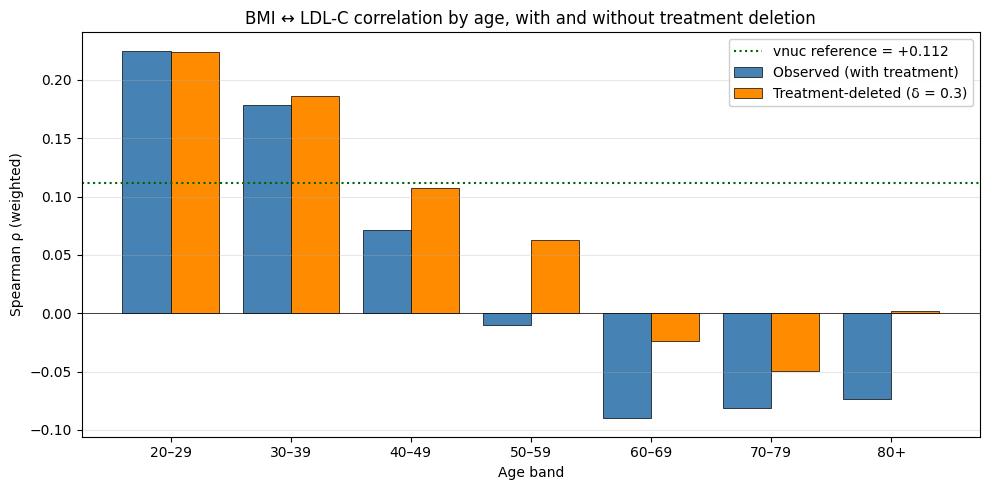

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
xs = np.arange(len(age_table))
width = 0.4
ax.bar(xs - width / 2, age_table["observed"], width, label="Observed (with treatment)",
       color="steelblue", edgecolor="black", linewidth=0.5)
ax.bar(xs + width / 2, age_table["untreated"], width,
       label=f"Treatment-deleted (δ = {STATIN_EFFICACY})",
       color="darkorange", edgecolor="black", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.5)
ax.axhline(VNUC_REFERENCE, linestyle=":", color="darkgreen",
           label=f"vnuc reference = +{VNUC_REFERENCE:.3f}")
ax.set_xticks(xs)
ax.set_xticklabels(age_table.index.astype(str))
ax.set_ylabel("Spearman ρ (weighted)")
ax.set_xlabel("Age band")
ax.set_title("BMI ↔ LDL-C correlation by age, with and without treatment deletion")
ax.legend(loc="upper right", framealpha=0.95)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## Sensitivity to the assumed treatment effect

The 30 % default is the central population estimate. CTT-collaboration
meta-analyses report mean LDL-C reductions around 35–40 % under
adherent statin therapy; real-world averages run lower because of
partial adherence. We sweep δ over the plausible range to confirm
the qualitative finding (treatment deletion pulls the correlation
back toward positive in the trial age band) does not depend on the
exact δ.

In [8]:
def trial_correlation_at_delta(df: pd.DataFrame, delta: float) -> float:
    df = df.copy()
    df["LBDLDL_adj"] = np.where(
        df["on_chol_med"] == 1, df["LBDLDL"] / (1.0 - delta), df["LBDLDL"]
    )
    return weighted_spearman(df["BMXBMI"], df["LBDLDL_adj"], df["WTMEC2YR"])


deltas = np.linspace(0.0, 0.55, 12)
sens = pd.DataFrame(
    {
        "delta": deltas,
        "trial_band_rho": [trial_correlation_at_delta(trial, d) for d in deltas],
        "pooled_rho":     [trial_correlation_at_delta(adults, d) for d in deltas],
    }
)
print(sens.round(4).to_string(index=False))

 delta  trial_band_rho  pooled_rho
  0.00         -0.0936      0.0932
  0.05         -0.0898      0.0999
  0.10         -0.0851      0.1068
  0.15         -0.0796      0.1139
  0.20         -0.0726      0.1210
  0.25         -0.0645      0.1280
  0.30         -0.0553      0.1348
  0.35         -0.0446      0.1413
  0.40         -0.0336      0.1472
  0.45         -0.0219      0.1524
  0.50         -0.0096      0.1571
  0.55          0.0024      0.1610


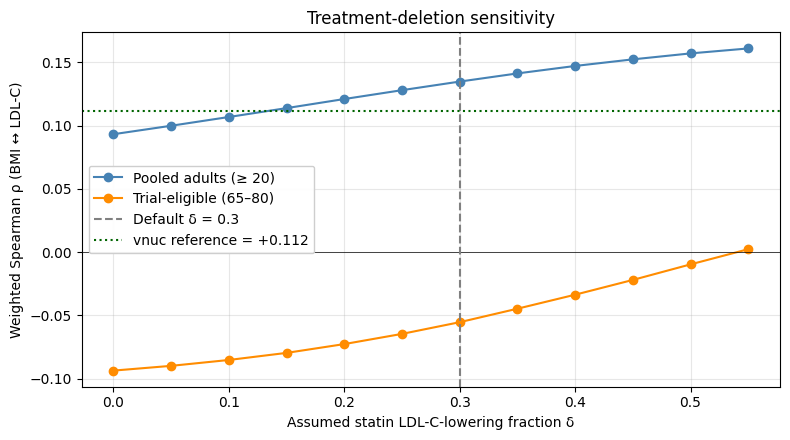

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sens["delta"], sens["pooled_rho"], marker="o", color="steelblue",
        label="Pooled adults (≥ 20)")
ax.plot(sens["delta"], sens["trial_band_rho"], marker="o", color="darkorange",
        label="Trial-eligible (65–80)")
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(STATIN_EFFICACY, linestyle="--", color="grey",
           label=f"Default δ = {STATIN_EFFICACY}")
ax.axhline(VNUC_REFERENCE, linestyle=":", color="darkgreen",
           label=f"vnuc reference = +{VNUC_REFERENCE:.3f}")
ax.set_xlabel("Assumed statin LDL-C-lowering fraction δ")
ax.set_ylabel("Weighted Spearman ρ (BMI ↔ LDL-C)")
ax.set_title("Treatment-deletion sensitivity")
ax.legend(loc="best", framealpha=0.95)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Summary: with and without treatment deletion

In [10]:
def summary_value(df: pd.DataFrame, ldl_col: str) -> float:
    return round(weighted_spearman(df["BMXBMI"], df[ldl_col], df["WTMEC2YR"]), 4)


summary = pd.DataFrame(
    {
        "all adults (≥ 20)": [
            summary_value(adults, "LBDLDL"),
            summary_value(adults, "LBDLDL_untreated"),
        ],
        "trial-eligible (65–80)": [
            summary_value(trial, "LBDLDL"),
            summary_value(trial, "LBDLDL_untreated"),
        ],
    },
    index=["observed (with treatment)", f"untreated (δ = {STATIN_EFFICACY})"],
)
print("Weighted Spearman correlation, BMI ↔ LDL-C")
print(summary.to_string())
print(f"\nVnuc reference (all-ages, age-invariant assumption): {VNUC_REFERENCE}")

Weighted Spearman correlation, BMI ↔ LDL-C
                           all adults (≥ 20)  trial-eligible (65–80)
observed (with treatment)             0.0932                 -0.0936
untreated (δ = 0.3)                   0.1348                 -0.0553

Vnuc reference (all-ages, age-invariant assumption): 0.1118
